# How Pittsburgh Bike Share Has Changed Over Time

Full POGOH trip history: **May 2022 (program launch) through August 2026** —
52 months, ~1.7M trips. Also tracks the station network's growth using 14
historical station-location snapshots.


In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from load_data import load_trips, load_station_history, load_pavement_markings

trips = load_trips()
stations_hist = load_station_history()
markings = load_pavement_markings()

print(f"{len(trips):,} trips | {trips.start_date.min().date()} to {trips.start_date.max().date()}")

1,703,174 trips | 2022-05-01 to 2026-08-31


## 1. Monthly ridership since launch

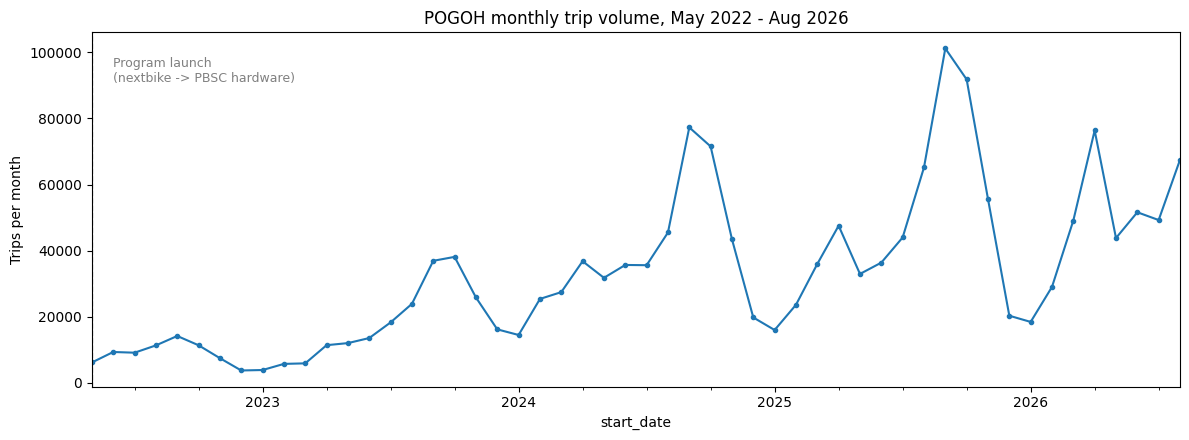

Year-over-year change by month (%):
start_date
2023-05-01     95.8
2023-06-01     45.5
2023-07-01    101.0
2023-08-01    111.5
2023-09-01    161.1
2023-10-01    236.4
2023-11-01    247.8
2023-12-01    337.3
2024-01-01    277.0
2024-02-01    345.9
2024-03-01    368.7
2024-04-01    223.9
2024-05-01    165.0
2024-06-01    163.8
2024-07-01     94.9
2024-08-01     90.5
2024-09-01    109.5
2024-10-01     87.8
2024-11-01     68.3
2024-12-01     22.3
2025-01-01     10.4
2025-02-01     -7.0
2025-03-01     31.1
2025-04-01     29.3
2025-05-01      3.7
2025-06-01      2.0
2025-07-01     23.6
2025-08-01     43.3
2025-09-01     30.9
2025-10-01     28.4
2025-11-01     28.1
2025-12-01      2.7
2026-01-01     15.4
2026-02-01     23.0
2026-03-01     36.6
2026-04-01     60.7
2026-05-01     33.0
2026-06-01     42.0
2026-07-01     12.0
2026-08-01      3.6
Freq: MS


In [2]:
monthly = trips.set_index('start_date').resample('MS').size()

fig, ax = plt.subplots(figsize=(12, 4.5))
monthly.plot(ax=ax, marker='o', markersize=3, color='#1f77b4')
ax.set_title('POGOH monthly trip volume, May 2022 - Aug 2026')
ax.set_ylabel('Trips per month')
ax.axvline(pd.Timestamp('2022-05-01'), color='gray', ls='--', lw=1, alpha=0.6)
ax.annotate('Program launch\n(nextbike -> PBSC hardware)', xy=(pd.Timestamp('2022-06-01'), monthly.max()*0.9),
            fontsize=9, color='gray')
plt.tight_layout()
plt.savefig('../docs/monthly_ridership_history.png', dpi=150)
plt.show()

yoy = monthly.pct_change(12).dropna() * 100
print('Year-over-year change by month (%):')
print(yoy.round(1).to_string())

## 2. Seasonality: same calendar pattern every year?

Pittsburgh winters are cold — does ridership follow a repeatable seasonal
curve, and has that curve shifted as the system matured?

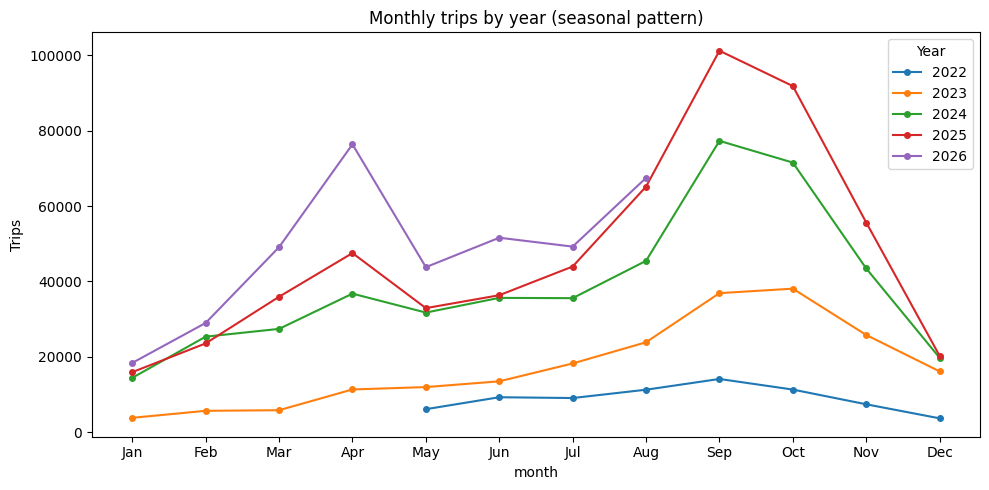

In [3]:
seasonal = trips.copy()
seasonal['year'] = seasonal['start_date'].dt.year
seasonal['month'] = seasonal['start_date'].dt.month
pivot = seasonal.groupby(['year', 'month']).size().unstack('year')

fig, ax = plt.subplots(figsize=(10, 5))
pivot.plot(ax=ax, marker='o', markersize=4)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_title('Monthly trips by year (seasonal pattern)')
ax.set_ylabel('Trips')
ax.legend(title='Year')
plt.tight_layout()
plt.savefig('../docs/seasonality_by_year.png', dpi=150)
plt.show()

## 3. Rider mix: member vs. casual share over time

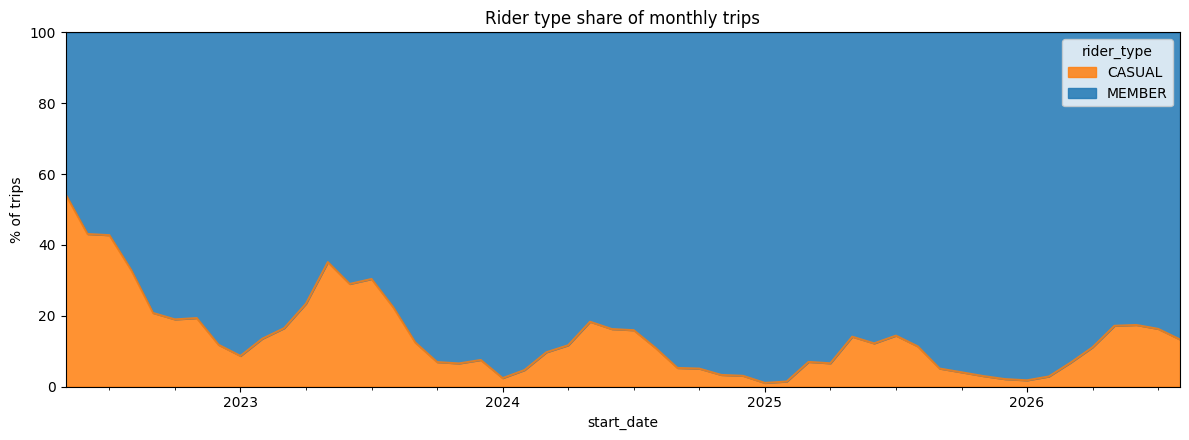

Casual share: first 6 months avg = 35.5 %
Casual share: last 6 months avg  = 13.7 %


In [4]:
mix = trips.set_index('start_date').groupby([pd.Grouper(freq='MS'), 'rider_type']).size().unstack('rider_type')
mix_share = mix.div(mix.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 4.5))
mix_share.plot(ax=ax, kind='area', stacked=True, color=['#ff7f0e', '#1f77b4'], alpha=0.85)
ax.set_title('Rider type share of monthly trips')
ax.set_ylabel('% of trips')
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig('../docs/rider_mix_over_time.png', dpi=150)
plt.show()

print('Casual share: first 6 months avg =', round(mix_share['CASUAL'].iloc[:6].mean(), 1), '%')
print('Casual share: last 6 months avg  =', round(mix_share['CASUAL'].iloc[-6:].mean(), 1), '%')

## 4. Trip duration over time

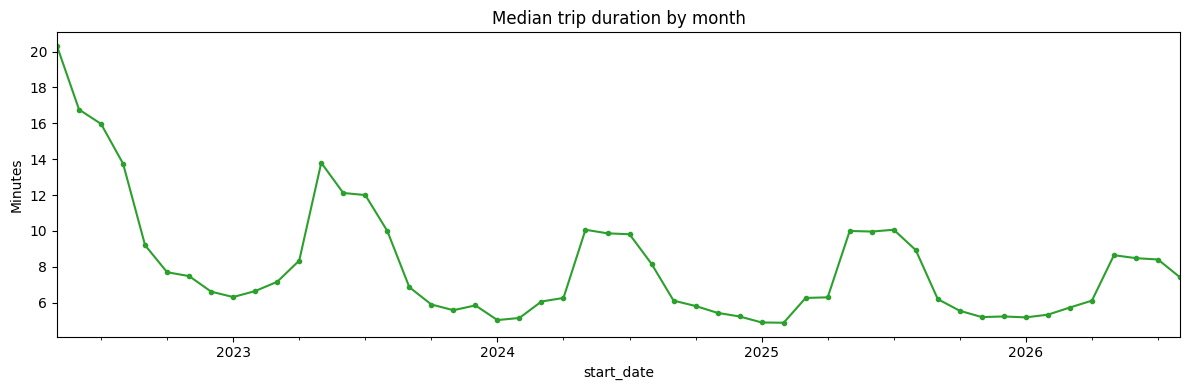

In [5]:
dur_monthly = trips[trips['duration_min'].between(0, 120)].set_index('start_date')['duration_min'].resample('MS').median()

fig, ax = plt.subplots(figsize=(12, 4))
dur_monthly.plot(ax=ax, color='#2ca02c', marker='o', markersize=3)
ax.set_title('Median trip duration by month')
ax.set_ylabel('Minutes')
plt.tight_layout()
plt.savefig('../docs/duration_over_time.png', dpi=150)
plt.show()

## 5. Station network growth vs. ridership growth

Does ridership growth track the station network's expansion, or does it keep
growing after the network plateaus (i.e. organic demand growth vs. supply-driven growth)?

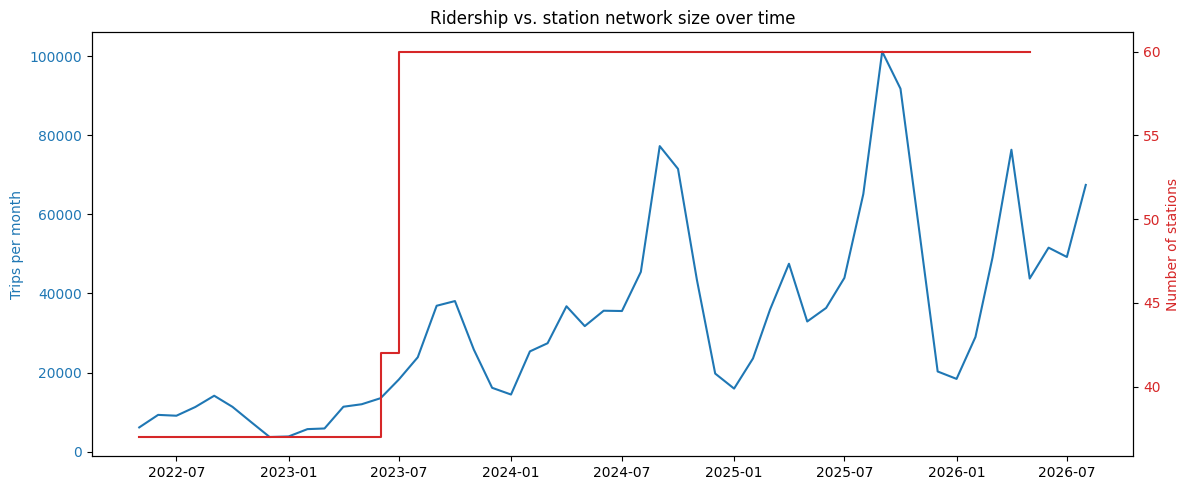

            n_stations  total_docks
2022-05-01        37.0        598.0
2022-06-01        37.0        598.0
2022-07-01        37.0        598.0
2022-08-01        37.0        598.0
2022-09-01        37.0        598.0
2022-10-01        37.0        598.0
2022-11-01        37.0        598.0
2022-12-01        37.0        598.0
2023-01-01        37.0        598.0
2023-02-01        37.0        598.0
2023-03-01        37.0        598.0
2023-04-01        37.0        598.0
2023-05-01        37.0        598.0
2023-06-01        42.0        693.0
2023-07-01        60.0       1056.0
2023-08-01        60.0       1052.0
2023-09-01        60.0       1052.0
2023-10-01        60.0       1061.0
2023-11-01        60.0       1061.0
2023-12-01        60.0       1061.0
2024-01-01        60.0       1061.0
2024-02-01        60.0       1061.0
2024-03-01        60.0       1061.0
2024-04-01        60.0       1061.0
2024-05-01        60.0       1061.0
2024-06-01        60.0       1061.0
2024-07-01        60.0      

In [6]:
network = stations_hist.groupby('snapshot_date').agg(n_stations=('id', 'count'), total_docks=('total_docks', 'sum'))
network = network.reindex(pd.date_range(network.index.min(), network.index.max(), freq='MS')).ffill()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(monthly.index, monthly.values, color='#1f77b4', label='Monthly trips')
ax1.set_ylabel('Trips per month', color='#1f77b4')
ax1.tick_params(axis='y', labelcolor='#1f77b4')

ax2 = ax1.twinx()
ax2.step(network.index, network['n_stations'], color='#d62728', where='post', label='Station count')
ax2.set_ylabel('Number of stations', color='#d62728')
ax2.tick_params(axis='y', labelcolor='#d62728')

ax1.set_title('Ridership vs. station network size over time')
fig.tight_layout()
plt.savefig('../docs/ridership_vs_network_growth.png', dpi=150)
plt.show()

print(network)

## 6. When is the system busiest? Day-of-week x hour heatmap

The classic bike-share visualization - exactly when (day + hour) demand
peaks across the full trip history.

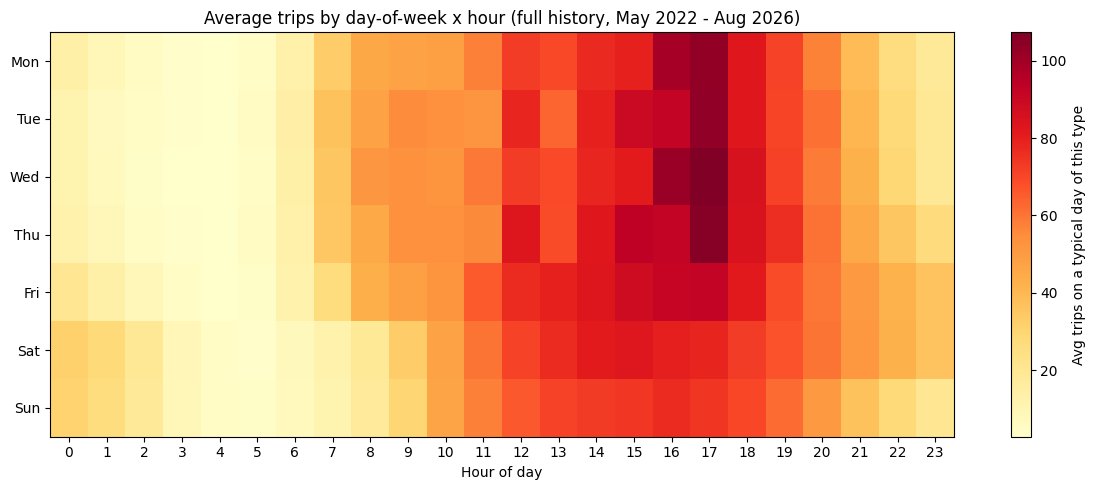

Busiest day overall: Fri
Busiest single day-hour combo: Wed at 17:00 (107 trips/hour on average)
Weekday evening rush (Mon-Fri, 4-6pm) avg: 99 trips/hour
Weekend midday (Sat-Sun, 11am-3pm) avg: 70 trips/hour


In [7]:
heat = trips.copy()
heat['date'] = heat['start_date'].dt.normalize()
heat['hour'] = heat['start_date'].dt.hour
heat['day_of_week'] = heat['start_date'].dt.dayofweek

# Average trips per hour on a TYPICAL day of that type (not a raw sum across 4+ years of history,
# which would just measure "how many Wednesdays existed" as much as demand intensity).
per_day_hour = heat.groupby(['date', 'day_of_week', 'hour']).size().rename('trips').reset_index()
pivot = per_day_hour.groupby(['day_of_week', 'hour'])['trips'].mean().unstack('hour').reindex(index=range(7)).fillna(0)
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd')
ax.set_yticks(range(7)); ax.set_yticklabels(day_labels)
ax.set_xticks(range(24)); ax.set_xticklabels(range(24))
ax.set_xlabel('Hour of day')
ax.set_title('Average trips by day-of-week x hour (full history, May 2022 - Aug 2026)')
fig.colorbar(im, ax=ax, label='Avg trips on a typical day of this type')
plt.tight_layout()
plt.savefig('../docs/demand_heatmap_dow_hour.png', dpi=150)
plt.show()

busiest_day = pivot.sum(axis=1).idxmax()
busiest_cell = pivot.stack().idxmax()
print(f"Busiest day overall: {day_labels[busiest_day]}")
print(f"Busiest single day-hour combo: {day_labels[busiest_cell[0]]} at {busiest_cell[1]}:00 "
      f"({pivot.loc[busiest_cell]:.0f} trips/hour on average)")
print(f"Weekday evening rush (Mon-Fri, 4-6pm) avg: {pivot.loc[0:4, [16,17]].values.mean():.0f} trips/hour")
print(f"Weekend midday (Sat-Sun, 11am-3pm) avg: {pivot.loc[5:6, [11,12,13,14]].values.mean():.0f} trips/hour")

## 7. Long view: cumulative bike-lane mileage (1980-2016)

Predates the bike-share program, but shows the multi-decade infrastructure
build-out that POGOH launched into.

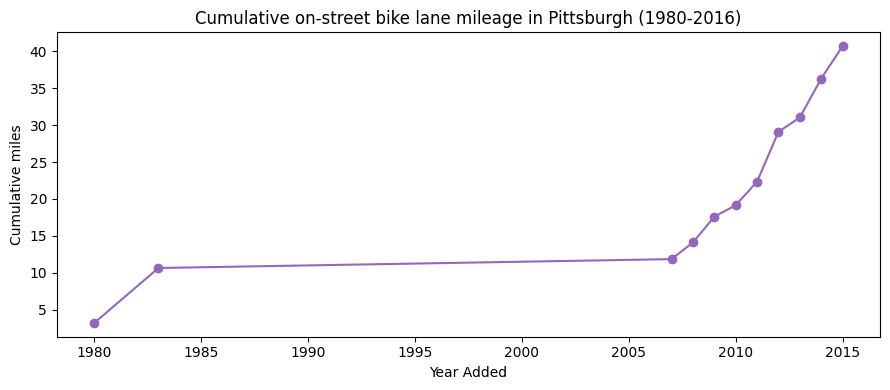

In [8]:
by_year = markings.groupby('Year Added')['Bike Lane Distance (Miles)'].sum().cumsum()

fig, ax = plt.subplots(figsize=(9, 4))
by_year.plot(ax=ax, marker='o', color='#9467bd')
ax.set_title('Cumulative on-street bike lane mileage in Pittsburgh (1980-2016)')
ax.set_ylabel('Cumulative miles')
plt.tight_layout()
plt.savefig('../docs/bike_lane_growth.png', dpi=150)
plt.show()

## Takeaways (fill in after reviewing the charts above)

- **Growth phase vs. plateau**: station count jumped from 37 -> 60 within the
  first ~14 months, then held flat for 3+ years — any ridership growth since
  mid-2023 reflects rising *demand per station*, not network expansion.
- **Seasonality**: compare the shape of each year's curve in section 2 —
  note whether winter troughs are getting shallower (more year-round riders)
  or the summer peak is growing faster than the winter floor.
- **Rider mix**: watch whether casual (tourist/one-off) share is rising or
  falling relative to members — a rising member share suggests the system is
  becoming more of a commuting tool than a novelty.
- **Duration**: a falling median duration over time often signals a shift
  toward utilitarian/commute trips rather than leisure riding.
